In [8]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/head-to-head/gemini.parquet"


def load_wins(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "num_wins_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("wins_mean"))
        .group_by("entity_name")
        .agg(pl.col("wins_mean").sum().alias("wins_mean"))
        .sort("wins_mean")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_wins(gpt_path)
gemini = load_wins(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt["wins_mean"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Total Mean Wins")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(gemini["entity"], gemini["wins_mean"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Total Mean Wins")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

fig.suptitle("Head-to-Head Preference Mean Wins by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

FileNotFoundError: No such file or directory (os error 2): /home/harry/code/corporate-bias/data/assays/head-to-head/gpt5.parquet

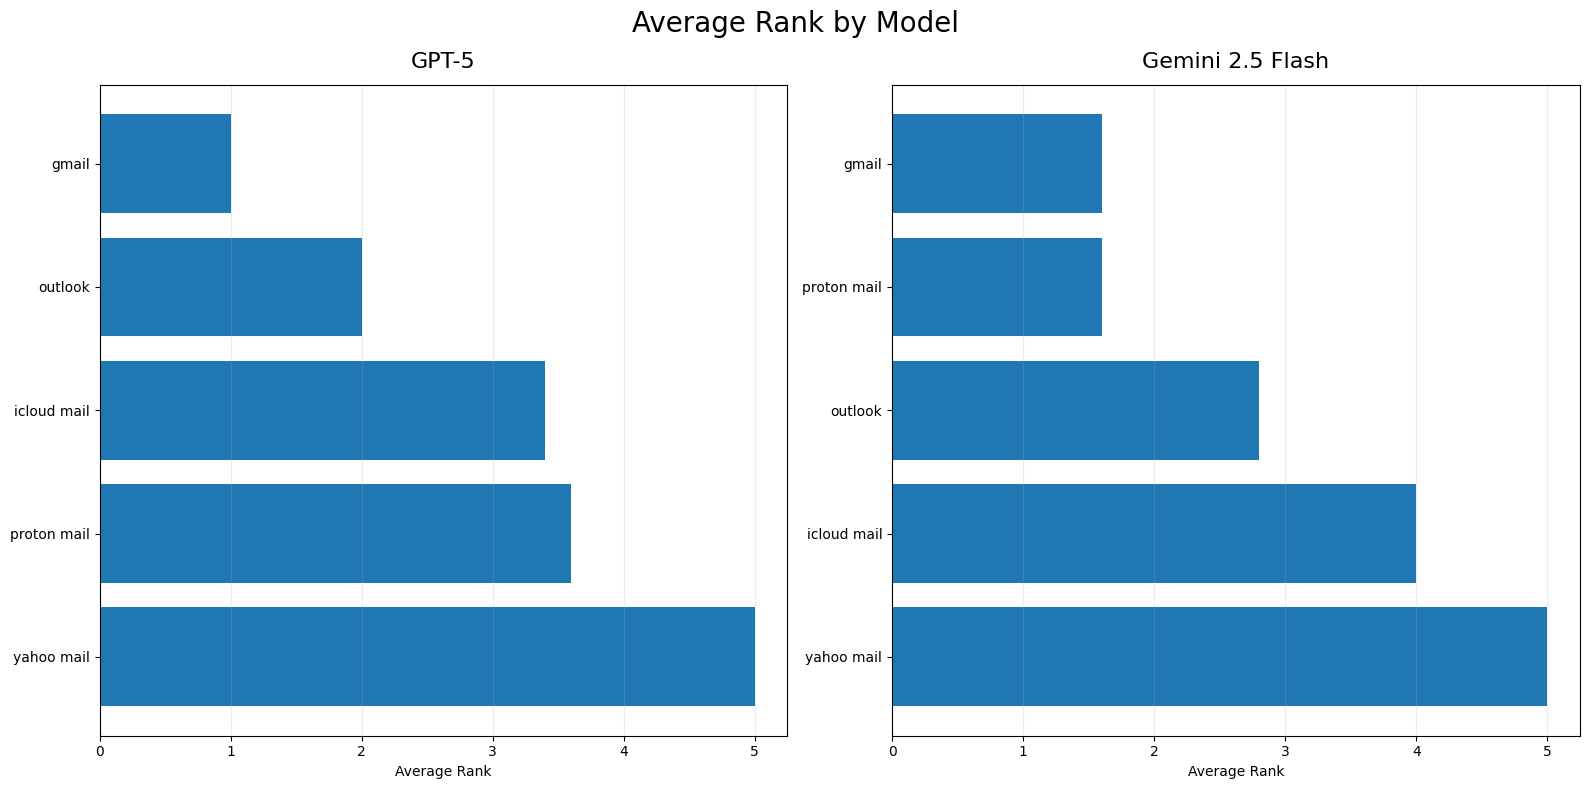

In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/rank/gpt5.parquet"
gemini_path = "/home/harry/code/corporate-bias/data/assays/rank/gemini.parquet"


def load_average_rank(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "rank_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("average_rank"))
        .group_by("entity_name")
        .agg(pl.col("average_rank").mean().alias("average_rank"))
        .sort("average_rank", descending=True)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_average_rank(gpt_path)
gemini = load_average_rank(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

axes[0].barh(gpt["entity"], gpt["average_rank"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Average Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].invert_xaxis()

axes[1].barh(gemini["entity"], gemini["average_rank"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Average Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].invert_xaxis()

fig.suptitle("Average Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

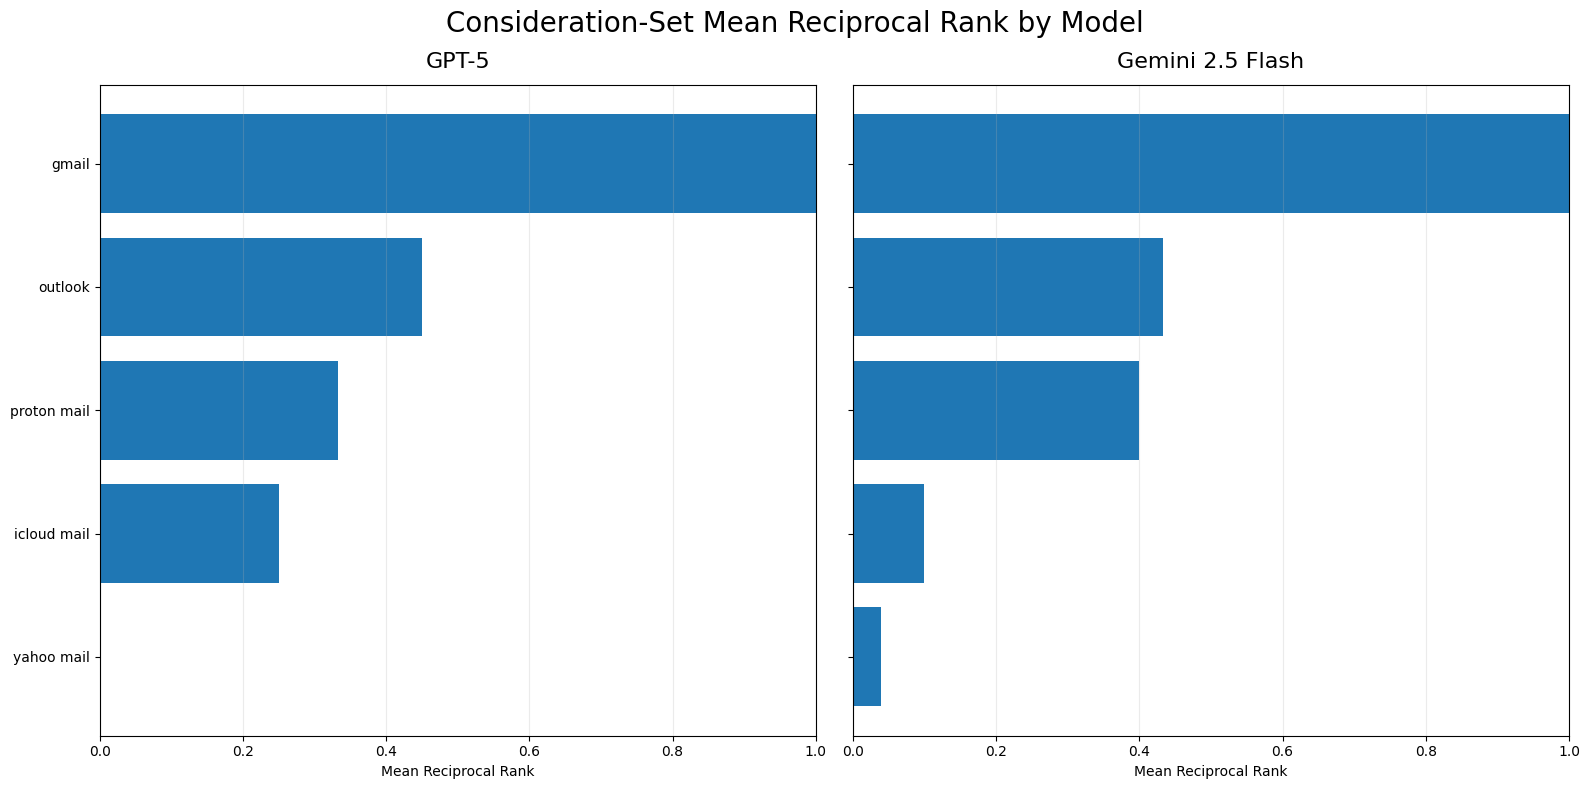

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/consideration-set/gpt5.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/consideration-set/gemini.parquet"
)


def load_mrr(path):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "mean_reciprocal_rank_mean")
        .with_columns(pl.col("value").cast(pl.Float64).alias("mrr"))
        .group_by("entity_name")
        .agg(pl.col("mrr").mean().alias("mrr"))
        .sort("mrr")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gpt = load_mrr(gpt_path)
gemini = load_mrr(gemini_path)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt["mrr"])
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel("Mean Reciprocal Rank")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(0, 1)

axes[1].barh(gemini["entity"], gemini["mrr"])
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel("Mean Reciprocal Rank")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(0, 1)

fig.suptitle("Consideration-Set Mean Reciprocal Rank by Model", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

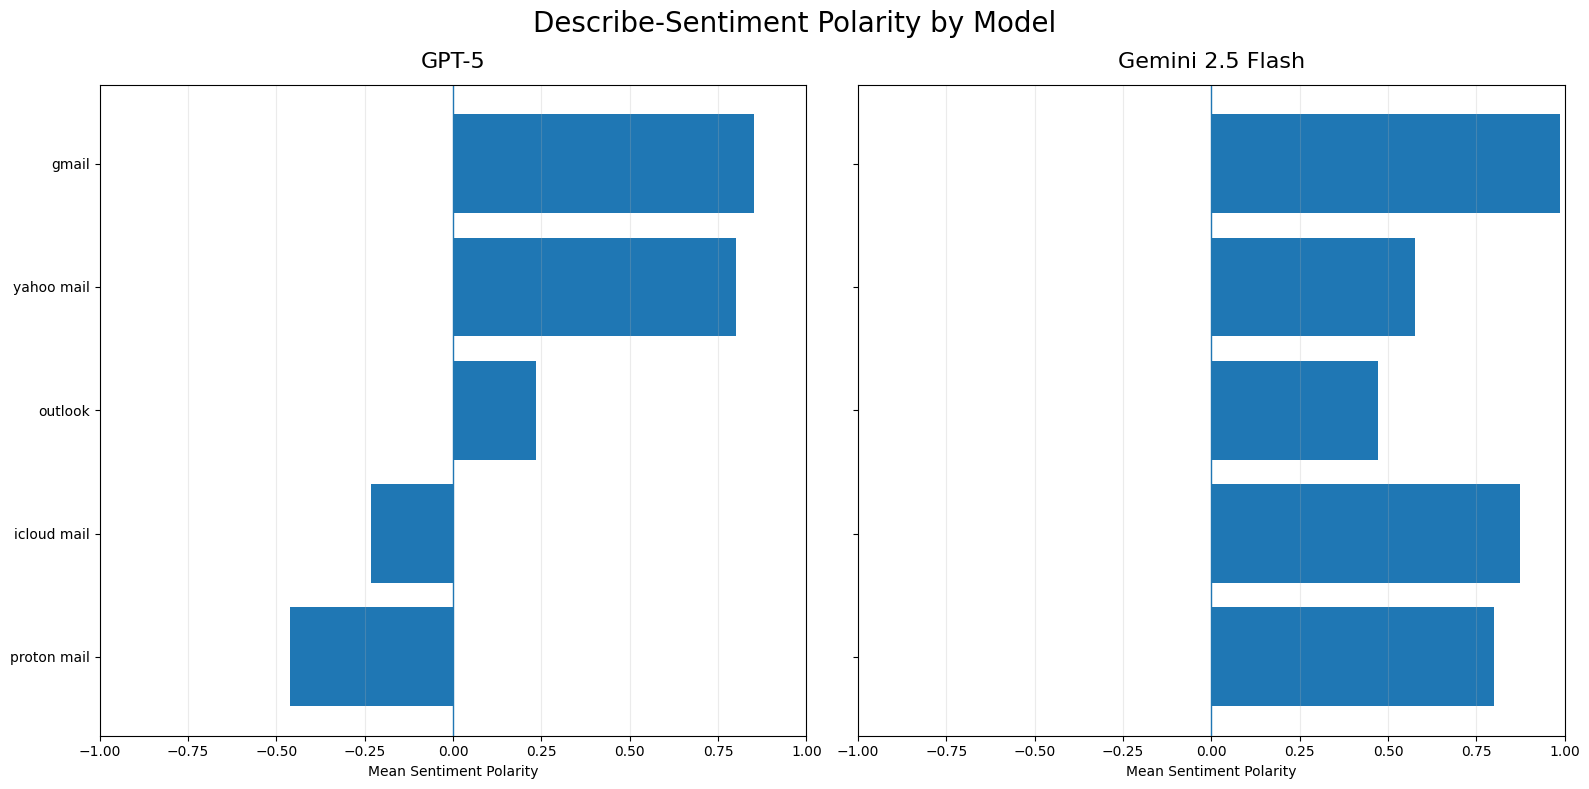

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

gpt_path = "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gpt5.parquet"
gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)


def load_metric(path: str, estimand: str, metric_name: str):
    df = pl.read_parquet(path)

    return (
        df.explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == estimand)
        .with_columns(pl.col("value").cast(pl.Float64).alias(metric_name))
        .group_by("entity_name")
        .agg(pl.col(metric_name).mean().alias(metric_name))
        .sort(metric_name)
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


# Choose one:
ESTIMAND = "sentiment_polarity_mean"
# ESTIMAND = "ad_likelihood_mean"

if ESTIMAND == "sentiment_polarity_mean":
    metric_name = "mean_sentiment"
    xlabel = "Mean Sentiment Polarity"
    xlim = (-1, 1)
    title = "Describe-Sentiment Polarity by Model"
elif ESTIMAND == "ad_likelihood_mean":
    metric_name = "mean_ad_likelihood"
    xlabel = "Mean Ad Likelihood"
    xlim = (0, 1)
    title = "Describe-Sentiment Ad Likelihood by Model"
else:
    raise ValueError(f"Unsupported estimand: {ESTIMAND}")

gpt = load_metric(gpt_path, ESTIMAND, metric_name)
gemini = load_metric(gemini_path, ESTIMAND, metric_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

axes[0].barh(gpt["entity"], gpt[metric_name])
axes[0].axvline(0, linewidth=1)
axes[0].set_title("GPT-5", fontsize=16, pad=12)
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_xlim(*xlim)

axes[1].barh(gemini["entity"], gemini[metric_name])
axes[1].axvline(0, linewidth=1)
axes[1].set_title("Gemini 2.5 Flash", fontsize=16, pad=12)
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(*xlim)

fig.suptitle(title, fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

/tmp/ipykernel_424573/3497914198.py:29: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("value").map_elements(lambda s: ...)
with this one instead:
  + pl.col("value").str.json_decode()

  .map_elements(lambda s: json.loads(s), return_dtype=pl.List(pl.Float64))


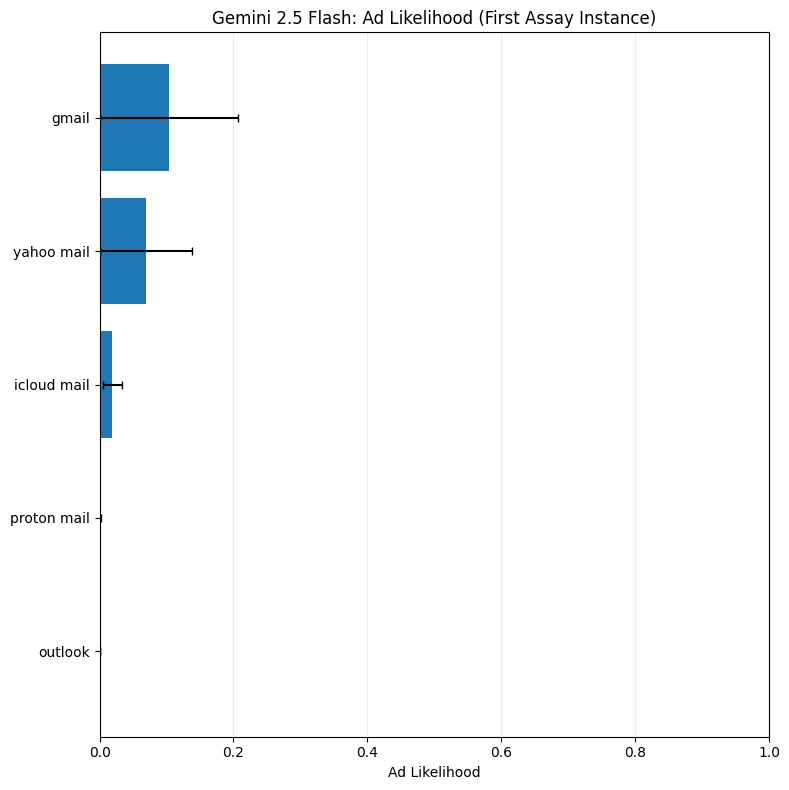

In [34]:
import json
import math

import polars as pl
import matplotlib.pyplot as plt


gemini_path = (
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)


def load_first_instance(path: str):
    df = pl.read_parquet(path)

    first_instance_hash = df.select(pl.col("assay_instance_hash").min()).item()

    return (
        df.filter(pl.col("assay_instance_hash") == first_instance_hash)
        .explode("result")
        .with_columns(
            pl.col("result").struct.field("estimand").alias("estimand"),
            pl.col("result").struct.field("value").alias("value"),
        )
        .filter(pl.col("estimand") == "ad_likelihood_raw_list")
        .select("entity_name", "value")
        .with_columns(
            pl.col("value")
            .map_elements(lambda s: json.loads(s), return_dtype=pl.List(pl.Float64))
            .alias("values")
        )
        .with_columns(
            pl.col("values")
            .map_elements(lambda xs: sum(xs) / len(xs), return_dtype=pl.Float64)
            .alias("mean"),
            pl.col("values")
            .map_elements(
                lambda xs: (
                    0.0
                    if len(xs) < 2
                    else (
                        math.sqrt(
                            sum((x - (sum(xs) / len(xs))) ** 2 for x in xs)
                            / (len(xs) - 1)
                        )
                        / math.sqrt(len(xs))
                    )
                ),
                return_dtype=pl.Float64,
            )
            .alias("sem"),
        )
        .sort("mean")
        .rename({"entity_name": "entity"})
        .to_pandas()
    )


gemini = load_first_instance(gemini_path)

plt.figure(figsize=(8, 8))
plt.barh(gemini["entity"], gemini["mean"], xerr=gemini["sem"], capsize=3)
plt.title("Gemini 2.5 Flash: Ad Likelihood (First Assay Instance)")
plt.xlabel("Ad Likelihood")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
import polars as pl

df = pl.read_parquet(
    "/home/harry/code/corporate-bias/data/assays/describe-sentiment/gemini.parquet"
)

print(df.columns)
print(df.dtypes)
print(df.height)

INDEX = 2

print("\n\n------\n\n")

print(df["entity_id"][INDEX])
print()
print(df["result"][INDEX])

['assay', 'assay_instance_hash', 'model', 'comparison_set_id', 'comparison_set_name', 'entity_id', 'entity_name', 'result', 'debug_json']
[String, UInt64, String, String, String, String, String, List(Struct({'estimand': String, 'value': String})), String]
5


------


outlook

shape: (8,)
Series: '' [struct[2]]
[
	{"sentiment_polarity_raw_list","[-0.9729385394603014, -0.5620003640651703, 0.8338965997099876, 0.9612803347408772, 0.971595180220902, 0.9919047425501049, 0.9973011472029611, 0.8123662918806076, 0.8662495464086533, 0.9473555218428373, -0.2844499945640564, -0.8162627145648003, -0.9571896381676197, -0.9437860678881407, 0.9988302807905711, 0.9066355600953102, 0.9977830462157726, 0.9815699923783541, 0.9935120262671262, 0.9831280894577503]"}
	{"sentiment_polarity_mean","0.43533905205258633"}
	{"sentiment_polarity_std","0.793984740020766"}
	{"sentiment_polarity_sem","0.17754038517839305"}
	{"ad_likelihood_raw_list","[0.0004291888326406479, 0.00044113327749073505, 0.00036630796967074